# Phase 3: Hardware & Temporal Anomaly Detection (Isolation Forest)
This notebook builds the machine learning pipeline for **Phase 3 (Incubation Loop Anomaly Detection)** of the **GuardIndia AI** platform.

## Objective
Identify synthetic identity fraud rings that reuse physical devices across multiple synthetic profiles or perform automated transaction/login bursts with mechanical timing regularity. We use the unsupervised **Isolation Forest** model to detect these patterns without needing explicit fraud labels.

## Pipeline Phases:
1. **Data Ingestion**: Load the `bank transactions data.csv` dataset.
2. **Data Cleaning**: Handle missing values and parse timestamps.
3. **Feature Engineering**:
   * `time_delta_seconds`: Seconds between current and previous transactions.
   * `accounts_per_device`: Count of unique accounts sharing the same device.
   * Select core features for training: `time_delta_seconds`, `accounts_per_device`, `LoginAttempts`, `TransactionAmount`.
4. **Preprocessing**: Standardize the features using a `StandardScaler`.
5. **Model Training**: Train an `IsolationForest` model on the scaled features.
6. **Evaluation**: Analyze anomaly scores, inspect the characteristics of flagged outliers, and plot the score distribution.
7. **Model Saving**: Serialize the trained model and scaler to the `ml_core/device_fingerprint/` directory.

## Step 1: Data Ingestion & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Style configuration for premium aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

# Load the dataset
data_path = '../datasets/bank transactions data.csv'
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


## Step 2: Data Cleaning

In [2]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Parse datetime fields
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Drop duplicates
df = df.drop_duplicates()
print(f"\nShape after dropping duplicates: {df.shape}")

Missing values before cleaning:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

Shape after dropping duplicates: (2512, 16)


## Step 3: Feature Engineering
We engineer features representing device sharing patterns and temporal velocities:
1. **`time_delta_seconds`**: Represents the speed of successive operations. High-frequency robotic scripts will have very low time deltas.
2. **`accounts_per_device`**: Identifies hardware collisions where multiple synthetic identities are operating out of the same device fingerprinted container (WebGL hash/DeviceID).

In [3]:
# 1. Calculate time delta between successive transactions
df['time_delta_seconds'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds().abs()

# 2. Calculate number of unique accounts per device
device_accounts = df.groupby('DeviceID')['AccountID'].nunique().reset_index()
device_accounts.columns = ['DeviceID', 'accounts_per_device']
df = df.merge(device_accounts, on='DeviceID', how='left')

# Select the target training features
features = ['time_delta_seconds', 'accounts_per_device', 'LoginAttempts', 'TransactionAmount']
X = df[features].copy()

# Fill missing values
X['time_delta_seconds'] = X['time_delta_seconds'].fillna(X['time_delta_seconds'].median())
X['accounts_per_device'] = X['accounts_per_device'].fillna(1)
X['LoginAttempts'] = X['LoginAttempts'].fillna(1)
X['TransactionAmount'] = X['TransactionAmount'].fillna(X['TransactionAmount'].median())

print("Engineered training features summary:")
print(X.describe())

Engineered training features summary:
       time_delta_seconds  accounts_per_device  LoginAttempts  \
count        2.512000e+03          2512.000000    2512.000000   
mean         4.211863e+07             4.541401       1.124602   
std          9.191205e+06             1.820685       0.602662   
min          2.657429e+07             1.000000       1.000000   
25%          3.408996e+07             3.000000       1.000000   
50%          4.195566e+07             4.000000       1.000000   
75%          5.016886e+07             6.000000       1.000000   
max          5.803267e+07             9.000000       5.000000   

       TransactionAmount  
count        2512.000000  
mean          297.593778  
std           291.946243  
min             0.260000  
25%            81.885000  
50%           211.140000  
75%           414.527500  
max          1919.110000  


## Step 4: Preprocessing (Standard Scaling)
Standardize features to ensure the Isolation Forest calculates tree cuts evenly across different numeric ranges.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled features sample (first 3 rows):")
print(X_scaled[:3])

Scaled features sample (first 3 rows):
[[ 0.80076203  0.80128606 -0.20679365 -0.97127547]
 [ 0.07670648  0.25193274 -0.20679365  0.26943961]
 [-0.04613757  0.25193274 -0.20679365 -0.58688162]]


## Step 5: Model Training (Isolation Forest)
We fit an Isolation Forest. We set `contamination=0.05` (representing 5% expected anomaly rate), which is typical for fraud incubation periods.

In [5]:
from sklearn.ensemble import IsolationForest

# Initialize the model
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Fit model on scaled features
model.fit(X_scaled)

# Compute anomaly scores and predictions
# decision_function returns the anomaly score (lower is more anomalous)
df['anomaly_score'] = model.decision_function(X_scaled)
# predict returns -1 for anomalies and 1 for normal values
df['anomaly_prediction'] = model.predict(X_scaled)
df['is_anomaly'] = df['anomaly_prediction'].map({1: 0, -1: 1})

print("Anomaly counts (0 = Normal, 1 = Anomalous):")
print(df['is_anomaly'].value_counts())
print("Proportion:")
print(df['is_anomaly'].value_counts(normalize=True))

Anomaly counts (0 = Normal, 1 = Anomalous):
is_anomaly
0    2386
1     126
Name: count, dtype: int64
Proportion:
is_anomaly
0    0.949841
1    0.050159
Name: proportion, dtype: float64


## Step 6: Evaluation & Anomaly Inspection
Let's visualize the distribution of anomaly scores and inspect the profiles that were flagged as anomalies.

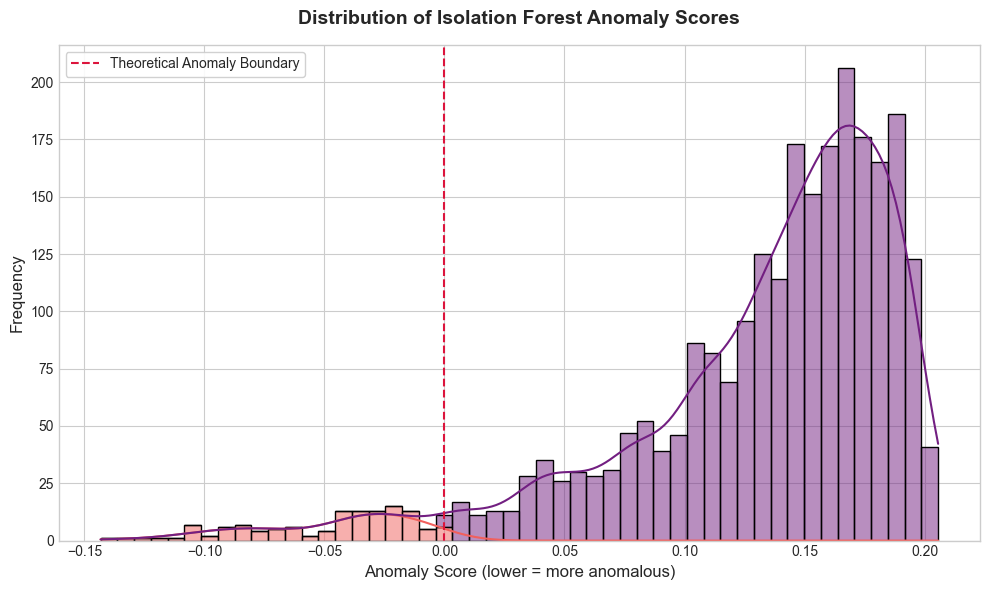


=== Characteristics of Flagged Anomalies ===
      time_delta_seconds  accounts_per_device  LoginAttempts  \
mean        4.209846e+07             4.579365       3.206349   
min         2.692631e+07             1.000000       1.000000   
max         5.794437e+07             9.000000       5.000000   

      TransactionAmount  
mean         582.849762  
min            1.930000  
max         1919.110000  

=== Characteristics of Normal Transactions ===
      time_delta_seconds  accounts_per_device  LoginAttempts  \
mean        4.211970e+07             4.539396       1.014669   
min         2.657429e+07             1.000000       1.000000   
max         5.803267e+07             9.000000       3.000000   

      TransactionAmount  
mean         282.529966  
min            0.260000  
max         1493.000000  


In [6]:
# Plot anomaly score distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='anomaly_score', hue='is_anomaly', bins=50, kde=True, palette='magma', multiple='stack')
plt.title('Distribution of Isolation Forest Anomaly Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Anomaly Score (lower = more anomalous)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='crimson', linestyle='--', label='Theoretical Anomaly Boundary')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('phase3_anomaly_scores_dist.png', dpi=300)
plt.show()

# Statistical comparison between normal and anomalous records
print("\n=== Characteristics of Flagged Anomalies ===")
print(df[df['is_anomaly'] == 1][features].describe().loc[['mean', 'min', 'max']])

print("\n=== Characteristics of Normal Transactions ===")
print(df[df['is_anomaly'] == 0][features].describe().loc[['mean', 'min', 'max']])

In [7]:
# Inspect the most anomalous transactions
print("Top 5 most extreme anomalies detected:")
df_sorted = df.sort_values(by='anomaly_score')
df_sorted[features + ['anomaly_score', 'is_anomaly']].head(5)

Top 5 most extreme anomalies detected:


,time_delta_seconds,accounts_per_device,LoginAttempts,TransactionAmount,anomaly_score,is_anomaly
1213,27532067.0,3,5,1192.20,-0.143256,1
274,27619422.0,4,5,1176.28,-0.130519,1
898,32623571.0,3,4,1531.31,-0.126683,1
2161,53536766.0,8,5,10.15,-0.115440,1
2124,57944374.0,7,4,737.46,-0.114844,1


## Step 7: Model & Scaler Serialization
Save the models to the project's core directory so they can be loaded by the FastAPI backend during runtime.

In [8]:
os.makedirs('../ml_core/device_fingerprint', exist_ok=True)

joblib.dump(model, '../ml_core/device_fingerprint/isolation_forest_model.pkl')
joblib.dump(scaler, '../ml_core/device_fingerprint/scaler_p3.pkl')

print("Model serialized to: ml_core/device_fingerprint/isolation_forest_model.pkl")
print("Scaler serialized to: ml_core/device_fingerprint/scaler_p3.pkl")

Model serialized to: ml_core/device_fingerprint/isolation_forest_model.pkl
Scaler serialized to: ml_core/device_fingerprint/scaler_p3.pkl
